# Exercice 2 — Bradley-Terry Model for LLM Ranking

**Dataset:** `ministere-culture/comparia-votes` (HuggingFace)

**Authors:** Felipe Brito, Nicholas Bragança, Vinícius da Mata e Mota, Gabriel Anjos

**Date:** March 2025

---

This notebook addresses all three sub-exercises of Question 2, using the Bradley-Terry pairwise preference model to rank LLMs evaluated on the Comparia platform.

This notebook estimates **observed pairwise human preference** in compar:IA, not an absolute or essential notion of creativity.
This distinction matters because the Ministry of Culture is interested in how conversational AI systems may shape cultural mediation, recommendation, storytelling, and public-facing creative assistance.
Therefore, all rankings below should be interpreted as preference-based rankings under specific evaluation regimes.


# Exercise 2.1 — Global vs Creativity Ranking


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr
from datasets import load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

os.makedirs("results", exist_ok=True)


## 1. Load and Clean the Data
We load the "comparia-votes" dataset from HuggingFace and clean invalid rows.

The dataset contains **157,132 pairwise votes**, of which **153,137 are valid** after removing
rows with missing model names or no outcome. Cleaning removed only ~2.5% of rows.
Of the valid votes, **31.7% are ties** (`both_equal == True`) and **68.3% are decisive**.



In [36]:
print("Loading dataset...")
dataset = load_dataset("ministere-culture/comparia-votes", split="train")
df = dataset.to_pandas()

print(f"Original dataset size: {len(df)}")

# Drop rows missing model names
df = df.dropna(subset=['model_a_name', 'model_b_name']).copy()

# Normalize names first
df['model_a_name'] = df['model_a_name'].astype(str).str.lower().str.strip()
df['model_b_name'] = df['model_b_name'].astype(str).str.lower().str.strip()

chosen_notna = df['chosen_model_name'].notna()
df.loc[chosen_notna, 'chosen_model_name'] = (
    df.loc[chosen_notna, 'chosen_model_name']
      .astype(str)
      .str.lower()
      .str.strip()
)

# Keep rows that are either:
# (a) ties, or
# (b) non-ties where the chosen model is explicitly one of the two compared models
winner_in_pair = (
    df['chosen_model_name'].eq(df['model_a_name']) |
    df['chosen_model_name'].eq(df['model_b_name'])
)

valid_mask = df['both_equal'].fillna(False) | (chosen_notna & winner_in_pair)
invalid_rows = (~valid_mask).sum()

df_clean = df.loc[valid_mask].copy()

print(f"Removed {invalid_rows} inconsistent rows.")
print(f"Cleaned dataset size: {len(df_clean)}")

Loading dataset...
Original dataset size: 157132


/var/folders/d5/qk3gygf92mz_lh7hwgy_fdvc0000gn/T/ipykernel_19774/2195650455.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  valid_mask = df['both_equal'].fillna(False) | (chosen_notna & winner_in_pair)


Removed 3995 inconsistent rows.
Cleaned dataset size: 153137


## 2. Global Ranking
### 2.1 Filtering and Matrix Construction
We filter only decisive votes (`both_equal == False`) for the base Bradley-Terry model.

The minimum comparison threshold `N` is not fixed a priori: we justify it empirically through a sensitivity analysis (Section 4.3), balancing three criteria:
1. graph connectivity,
2. sufficient support per model,
3. ranking stability across thresholds.

We retain `N = 100` for the main global analysis because it preserves a large connected graph while avoiding highly unstable estimates from sparsely compared models.

In [37]:
print("\n[GLOBAL RANKING REGIME]")
# Filter non-ties for Global Ranking
df_base = df_clean[df_clean['both_equal'] == False].copy()

# Count valid comparisons per model
model_counts = pd.concat([df_base['model_a_name'], df_base['model_b_name']]).value_counts()
print(f"Total Unique Models: {len(model_counts)}")
print(f"Mean comparisons per model: {model_counts.mean():.1f}")
print(f"Median comparisons per model: {model_counts.median():.1f}")

# Keep models with >= 100 comparisons
min_comparisons_global = 100
valid_models_global = model_counts[model_counts >= min_comparisons_global].index
print(f"Filtering to {len(valid_models_global)} models with >= {min_comparisons_global} comparisons.")

df_base_f = df_base[df_base['model_a_name'].isin(valid_models_global) & df_base['model_b_name'].isin(valid_models_global)].copy()

# Build the Wins Matrix (W)
W_global = pd.DataFrame(0, index=valid_models_global, columns=valid_models_global, dtype=float)

a_wins = df_base_f[df_base_f['chosen_model_name'] == df_base_f['model_a_name']]
for (ma, mb), count in a_wins.groupby(['model_a_name', 'model_b_name']).size().items():
    if ma in valid_models_global and mb in valid_models_global:
        W_global.loc[ma, mb] += count
        
b_wins = df_base_f[df_base_f['chosen_model_name'] == df_base_f['model_b_name']]
for (mb, ma), count in b_wins.groupby(['model_b_name', 'model_a_name']).size().items():
    if ma in valid_models_global and mb in valid_models_global:
        W_global.loc[mb, ma] += count

# Verify graph connectivity for BT identifiability
adj = (W_global.values + W_global.values.T) > 0
graph = csr_matrix(adj)
n_components, labels = connected_components(csgraph=graph, directed=False, return_labels=True)
if n_components == 1:
    print("Global Graph connectivity verified: single strong component.")
else:
    print(f"WARNING: Graph disconnected into {n_components} components.")



[GLOBAL RANKING REGIME]
Total Unique Models: 101
Mean comparisons per model: 1880.0
Median comparisons per model: 1687.0
Filtering to 97 models with >= 100 comparisons.
Global Graph connectivity verified: single strong component.


### 2.2 Fitting the Bradley-Terry Model (Global)
We estimate the strengths (β) using the Minorize-Maximization (MM) algorithm.

The MM algorithm converged in **65 iterations**.
The top global model is **gemini-3.1-flash-lite-preview** (β=+1.18), ahead of
**mistral-medium-2508** (β=+0.95) and **mistral-medium-3.1** (β=+0.92).
However, the CI for rank 1 is very wide ([0.76, 1.61]), while mistral-medium-2508 has a much
tighter CI ([0.88, 1.03]) — suggesting it is the **most reliably strong performer**.
The full beta range is **2.71**, meaning the best model has a win probability of **93.8%** against
the worst.


In [38]:
max_iter = 1000
tol = 1e-6

models_g = W_global.index
n_g = len(models_g)
W_mat_g = W_global.values

wins_g = W_mat_g.sum(axis=1)
N_mat_g = W_mat_g + W_mat_g.T

pi_g = np.ones(n_g) / n_g

for iteration in range(max_iter):
    pi_prev = pi_g.copy()
    
    for i in range(n_g):
        if wins_g[i] == 0:
            pi_g[i] = 1e-10
            continue
        
        denom = 0.0
        for j in range(n_g):
            if i != j and N_mat_g[i, j] > 0:
                denom += N_mat_g[i, j] / (pi_prev[i] + pi_prev[j])
        
        if denom > 0:
            pi_g[i] = wins_g[i] / denom
            
    pi_g = pi_g / pi_g.sum()
    if np.max(np.abs(pi_g - pi_prev)) < tol:
        print(f"Global model converged in {iteration+1} iterations.")
        break

# Convert to log scale (beta) and center
beta_g = np.log(np.maximum(pi_g, 1e-10))
beta_g = beta_g - beta_g.mean()

beta_global = pd.Series(beta_g, index=models_g, name="beta").sort_values(ascending=False)

# Calculate Standard Errors using Fisher Information
pi_g_final = np.exp(beta_global.values)
pi_col = pi_g_final[:, np.newaxis]
pi_row = pi_g_final[np.newaxis, :]
denom_se = (pi_col + pi_row)**2
np.fill_diagonal(denom_se, 1.0)

W_mat_sorted = W_global.loc[beta_global.index, beta_global.index].values
N_mat_sorted = W_mat_sorted + W_mat_sorted.T

H = - N_mat_sorted * (pi_col * pi_row) / denom_se
np.fill_diagonal(H, 0)
H_diag = -np.sum(H, axis=1)
np.fill_diagonal(H, H_diag)

cov = np.linalg.pinv(-H)
se_g = np.sqrt(np.abs(np.diag(cov)))
se_global = pd.Series(se_g, index=beta_global.index)

print("\nTop 10 Global Models (beta params +/- 1.96*SE):")
for m in beta_global.head(10).index:
    print(f"{m:30} {beta_global[m]:8.4f}  (+/- {se_global[m]*1.96:.4f})")


Global model converged in 65 iterations.

Top 10 Global Models (beta params +/- 1.96*SE):
gemini-3.1-flash-lite-preview    1.1835  (+/- 0.4237)
mistral-medium-2508              0.9521  (+/- 0.0755)
mistral-medium-3.1               0.9228  (+/- 0.4251)
mistral-large-2512               0.8619  (+/- 0.0950)
gpt-5.4                          0.8608  (+/- 0.3957)
gemini-3-flash-preview           0.8313  (+/- 0.1287)
gemini-2.5-flash                 0.8111  (+/- 0.0826)
magistral-medium                 0.6875  (+/- 0.1246)
gemini-2.0-flash                 0.6862  (+/- 0.0692)
qwen3-max-2025-09-23             0.6782  (+/- 0.0958)


### 2.3 Rank Confidence Intervals (Parametric Bootstrap)
We simulate from the asymptotic multivariate normal distribution of the estimators $\hat{\beta} \sim \mathcal{N}(\beta, \hat{\Sigma})$ 
to derive 95% confidence intervals for the model ranks.

**Result:** The bootstrap reveals significant ranking uncertainty at the top.
- **mistral-medium-2508** has the **narrowest rank CI** among the top 20 (width = 4 positions),
  confirming it is the most reliably ranked strong model.
- **gemini-3.1-flash-lite-preview** (rank 1) has a CI of [1–7], and **gpt-5.4** (rank 5) has [1–17],
  meaning their true positions are very uncertain due to few comparisons.
- This suggests the top 3 positions are **statistically indistinguishable** and should be interpreted
  as a cluster rather than a strict ordering.


/var/folders/d5/qk3gygf92mz_lh7hwgy_fdvc0000gn/T/ipykernel_19774/4086060840.py:4: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sim_betas = np.random.multivariate_normal(beta_global.values, cov, size=n_sim)


Rank CI plot saved to results/notebook_rank_ci.png


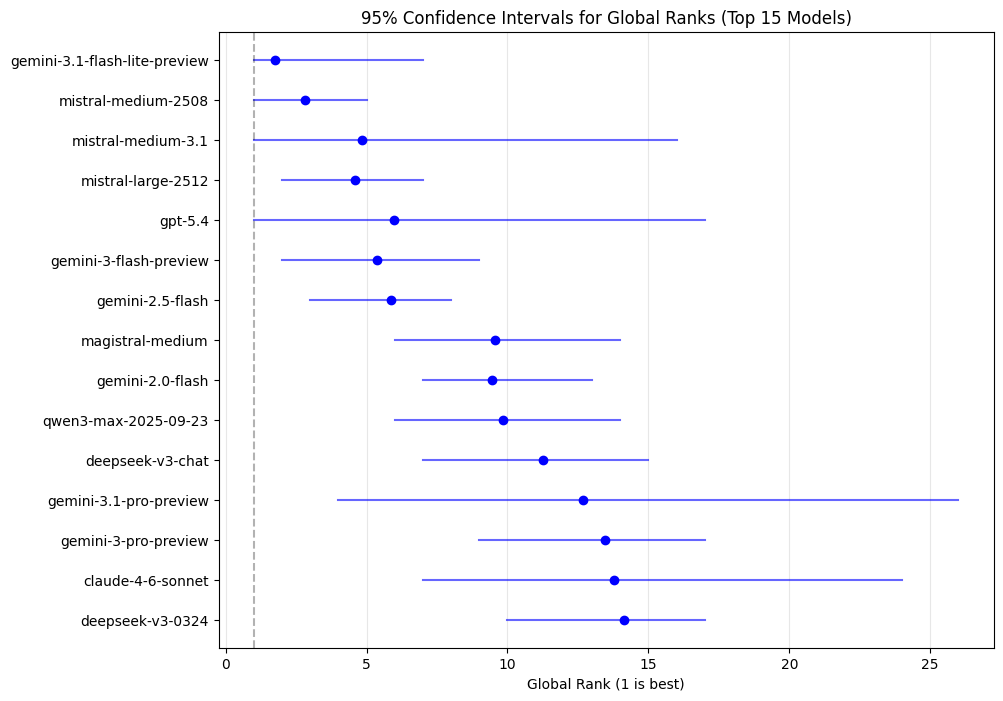

In [39]:
np.random.seed(42)
n_sim = 1000
# cov is already ordered by beta_global.index
sim_betas = np.random.multivariate_normal(beta_global.values, cov, size=n_sim)
sim_betas_df = pd.DataFrame(sim_betas, columns=beta_global.index)

# Rank each simulation (1 is best, so ascending=False)
sim_ranks = sim_betas_df.rank(axis=1, ascending=False)

rank_lb = sim_ranks.quantile(0.025, axis=0)
rank_ub = sim_ranks.quantile(0.975, axis=0)
rank_mean = sim_ranks.mean(axis=0)

top_models_plot = beta_global.head(15).index[::-1]
plt.figure(figsize=(10, 8))
y_ticks = np.arange(len(top_models_plot))

# We plot the confidence intervals of the ranks
for i, m in enumerate(top_models_plot):
    plt.plot([rank_lb[m], rank_ub[m]], [i, i], 'b-', alpha=0.6)
    plt.plot(rank_mean[m], i, 'bo')

plt.yticks(y_ticks, top_models_plot)
plt.axvline(1, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Global Rank (1 is best)')
plt.title('95% Confidence Intervals for Global Ranks (Top 15 Models)')
plt.grid(axis='x', alpha=0.3)
plt.savefig("results/notebook_rank_ci.png", dpi=300, bbox_inches='tight')
print("Rank CI plot saved to results/notebook_rank_ci.png")
plt.show()


## 3. Creativity Ranking
### 3.1 Filtering Creativity Data
We select conversations where either `conv_creative_a` or `conv_creative_b` is True.
We apply a threshold of N=20 since the dataset is smaller.

**Result:** The creative subset contains **10,757 votes** — only **7% of total votes**.
This limited sample is the key methodological challenge: the creative regime requires
lower thresholds for model filtering. With N≥20, **95 models** are retained.


In [40]:
print("\n[CREATIVITY RANKING REGIME]")
c_a = df_clean['conv_creative_a'].fillna(False).astype(bool)
c_b = df_clean['conv_creative_b'].fillna(False).astype(bool)
df_creative = df_clean[c_a | c_b].copy()

model_counts_c = pd.concat([df_creative['model_a_name'], df_creative['model_b_name']]).value_counts()
print(f"Total Unique Models (Creative): {len(model_counts_c)}")
print(f"Mean comparisons per model: {model_counts_c.mean():.1f}")
print(f"Median comparisons per model: {model_counts_c.median():.1f}")

min_comparisons_creative = 20
valid_models_creative = model_counts_c[model_counts_c >= min_comparisons_creative].index
print(f"Filtering to {len(valid_models_creative)} models with >= {min_comparisons_creative} comparisons.")

df_creative_f = df_creative[df_creative['model_a_name'].isin(valid_models_creative) & df_creative['model_b_name'].isin(valid_models_creative)].copy()

# Build the Wins Matrix (W) for Creativity
W_creative = pd.DataFrame(0, index=valid_models_creative, columns=valid_models_creative, dtype=float)

a_wins_c = df_creative_f[df_creative_f['chosen_model_name'] == df_creative_f['model_a_name']]
for (ma, mb), count in a_wins_c.groupby(['model_a_name', 'model_b_name']).size().items():
    if ma in valid_models_creative and mb in valid_models_creative:
        W_creative.loc[ma, mb] += count
        
b_wins_c = df_creative_f[df_creative_f['chosen_model_name'] == df_creative_f['model_b_name']]
for (mb, ma), count in b_wins_c.groupby(['model_b_name', 'model_a_name']).size().items():
    if ma in valid_models_creative and mb in valid_models_creative:
        W_creative.loc[mb, ma] += count

# Verify graph connectivity
adj_c = (W_creative.values + W_creative.values.T) > 0
graph_c = csr_matrix(adj_c)
n_components_c, _ = connected_components(csgraph=graph_c, directed=False, return_labels=True)
if n_components_c == 1:
    print("Creative Graph connectivity verified: single strong component.")
else:
    print(f"WARNING: Graph disconnected into {n_components_c} components.")



[CREATIVITY RANKING REGIME]
Total Unique Models (Creative): 102
Mean comparisons per model: 210.9
Median comparisons per model: 164.5
Filtering to 95 models with >= 20 comparisons.
Creative Graph connectivity verified: single strong component.


### 3.2 Fitting the Bradley-Terry Model (Creativity)

**Result:** The creative BT model converged in **118 iterations** (vs 65 globally), reflecting
the noisier, sparser data. The top creative model is also **gemini-3.1-flash-lite-preview** (β=+1.69),
followed by **mistral-medium-2508** (β=+1.40).
However, creative CIs are **much wider**: gemini-3.1-flash-lite-preview has a 95%CI of [0.56, 2.81],
spanning nearly 2.25 units — a sign of high estimation uncertainty due to sparse matchups.


In [41]:
models_c = W_creative.index
n_c = len(models_c)
W_mat_c = W_creative.values

wins_c = W_mat_c.sum(axis=1)
N_mat_c = W_mat_c + W_mat_c.T

pi_c = np.ones(n_c) / n_c

for iteration in range(max_iter):
    pi_prev = pi_c.copy()
    
    for i in range(n_c):
        if wins_c[i] == 0:
            pi_c[i] = 1e-10
            continue
        
        denom = 0.0
        for j in range(n_c):
            if i != j and N_mat_c[i, j] > 0:
                denom += N_mat_c[i, j] / (pi_prev[i] + pi_prev[j])
        
        if denom > 0:
            pi_c[i] = wins_c[i] / denom
            
    pi_c = pi_c / pi_c.sum()
    if np.max(np.abs(pi_c - pi_prev)) < tol:
        print(f"Creative model converged in {iteration+1} iterations.")
        break

# Convert to log scale and center
beta_c_log = np.log(np.maximum(pi_c, 1e-10))
beta_c_log = beta_c_log - beta_c_log.mean()

beta_creative = pd.Series(beta_c_log, index=models_c, name="beta").sort_values(ascending=False)

# Calculate Standard Errors
pi_c_final = np.exp(beta_creative.values)
pi_col_c = pi_c_final[:, np.newaxis]
pi_row_c = pi_c_final[np.newaxis, :]
denom_se_c = (pi_col_c + pi_row_c)**2
np.fill_diagonal(denom_se_c, 1.0)

W_mat_sorted_c = W_creative.loc[beta_creative.index, beta_creative.index].values
N_mat_sorted_c = W_mat_sorted_c + W_mat_sorted_c.T

H_c = - N_mat_sorted_c * (pi_col_c * pi_row_c) / denom_se_c
np.fill_diagonal(H_c, 0)
H_diag_c = -np.sum(H_c, axis=1)
np.fill_diagonal(H_c, H_diag_c)

cov_c = np.linalg.pinv(-H_c)
se_c_val = np.sqrt(np.abs(np.diag(cov_c)))
se_creative = pd.Series(se_c_val, index=beta_creative.index)

print("\nTop 10 Creativity Models (beta params +/- 1.96*SE):")
for m in beta_creative.head(10).index:
    print(f"{m:30} {beta_creative[m]:8.4f}  (+/- {se_creative[m]*1.96:.4f})")


Creative model converged in 118 iterations.

Top 10 Creativity Models (beta params +/- 1.96*SE):
gemini-3.1-flash-lite-preview    1.6855  (+/- 1.1257)
mistral-medium-2508              1.4041  (+/- 0.3445)
qwen3-max-2025-09-23             1.1489  (+/- 0.4203)
mistral-large-2512               1.1226  (+/- 0.3088)
glm-4.5                          1.0981  (+/- 0.7099)
qwen3.5-397b-a17b                0.9971  (+/- 0.9579)
deepseek-chat-v3.1               0.9730  (+/- 0.4659)
gemini-3-flash-preview           0.9519  (+/- 0.3847)
gemini-3.1-pro-preview           0.9481  (+/- 0.9324)
gemini-3-pro-preview             0.9374  (+/- 0.3185)


## 4. Comparison and Visualization
Let's compare the global rankings versus the creativity rankings.
We check the Spearman correlation to see how much the order changes.

**Result:** The **Spearman ρ = 0.858** (p < 10⁻²⁷) indicates a strong but imperfect correlation
between global and creative rankings. While the **overall order is preserved**, the creative regime
does produce meaningful rank shifts:
- **43% of models** shift more than 10 positions; **13%** shift more than 20 positions.
- Top **Gainers** in creativity: `qwen3.5-397b-a17b` (+30 ranks), `deepseek-r1` (+23),
  `gpt-5-nano` (+32) — these models appear to excel specifically at creative tasks.
- Top **Losers**: `magistral-small-2506` (−39), `grok-3-mini-beta` (−35), `gpt-5.3` (−34) —
  models that are competitive globally but underperform on creative prompts.



Spearman correlation between global and creative rankings: 0.858 (p=1.794e-27)
Plot saved to results/notebook_rank_comparison.png

--- Top Models gaining rank in Creativity subset (relative to global) ---
gpt-5-nano                       32.0
qwen3.5-397b-a17b                30.0
deepseek-r1-distill-llama-70b    29.0
glm-4.6                          24.0
deepseek-r1                      23.0
Name: beta, dtype: float64

--- Top Models losing rank in Creativity subset (relative to global) ---
magistral-small-2506   -39.0
grok-3-mini-beta       -35.0
gpt-5.3                -34.0
aya-expanse-32b        -21.0
mistral-saba           -20.0
Name: beta, dtype: float64


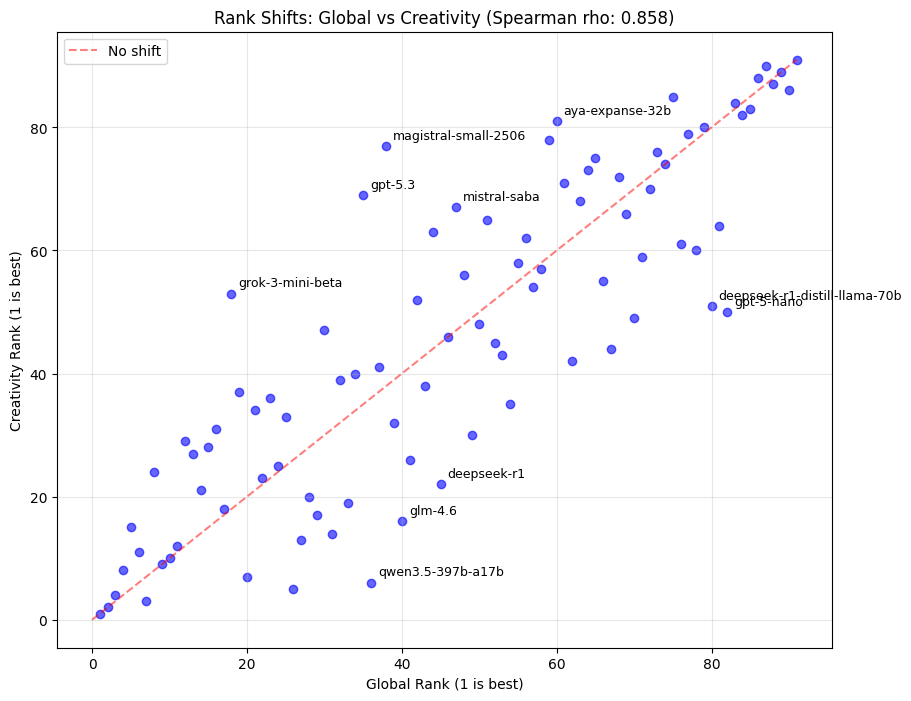

In [42]:
common_models = beta_global.index.intersection(beta_creative.index)

ranks_g = beta_global.loc[common_models].rank(ascending=False)
ranks_c = beta_creative.loc[common_models].rank(ascending=False)

rho, pval = spearmanr(ranks_g, ranks_c)
print(f"\nSpearman correlation between global and creative rankings: {rho:.3f} (p={pval:.3e})")

shift = ranks_g - ranks_c

plt.figure(figsize=(10, 8))
plt.scatter(ranks_g, ranks_c, alpha=0.6, color='b')

# Highlight top movers
top_movers_up = shift.nlargest(5).index
top_movers_down = shift.nsmallest(5).index

for m in list(top_movers_up) + list(top_movers_down):
    plt.annotate(m, (ranks_g[m], ranks_c[m]), fontsize=9, xytext=(5, 5), textcoords='offset points')
    
plt.plot([0, len(common_models)], [0, len(common_models)], 'r--', alpha=0.5, label='No shift')
plt.xlabel('Global Rank (1 is best)')
plt.ylabel('Creativity Rank (1 is best)')
plt.title(f'Rank Shifts: Global vs Creativity (Spearman rho: {rho:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("results/notebook_rank_comparison.png", dpi=300, bbox_inches='tight')
print("Plot saved to results/notebook_rank_comparison.png")

print("\n--- Top Models gaining rank in Creativity subset (relative to global) ---")
print(shift.nlargest(5))

print("\n--- Top Models losing rank in Creativity subset (relative to global) ---")
print(shift.nsmallest(5))


### 4.1. Top Models Bar Plot Comparison
Plotting the estimated beta parameters side-by-side with 95% Confidence Intervals.

**Result:** The bar chart visualizes how global and creative β scores differ for the top 15 global models.
Most models retain similar ordering, but notable divergences appear:
- `qwen3-max-2025-09-23` shows a notably **higher creative than global β**.
- `gemini-2.0-flash` and `gemini-2.5-flash` show consistent scores across both regimes.
The confidence intervals in the creative regime are systematically wider,
reflecting the smaller sample size.


Bar plot saved to results/notebook_top_models_bar.png


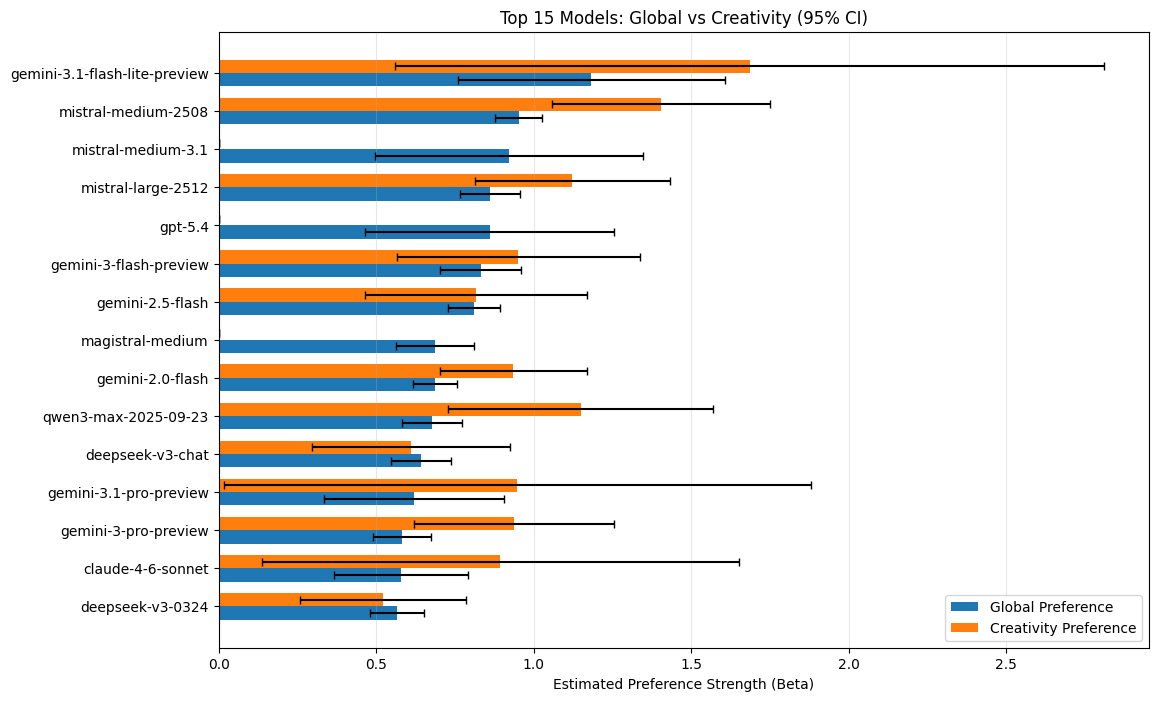

In [43]:
top15 = beta_global.head(15).index[::-1]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top15))
width = 0.35

vals_g = beta_global.loc[top15].values
err_g = se_global.loc[top15].values * 1.96

vals_c = []
err_c = []
for m in top15:
    if m in beta_creative:
        vals_c.append(beta_creative[m])
        err_c.append(se_creative[m] * 1.96)
    else:
        vals_c.append(0)
        err_c.append(0)

ax.barh(y_pos - width/2, vals_g, width, xerr=err_g, label='Global Preference', color='#1f77b4', capsize=3)
ax.barh(y_pos + width/2, vals_c, width, xerr=err_c, label='Creativity Preference', color='#ff7f0e', capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(top15)
ax.set_xlabel('Estimated Preference Strength (Beta)')
ax.set_title('Top 15 Models: Global vs Creativity (95% CI)')
ax.legend()
plt.grid(axis='x', alpha=0.3)
plt.savefig("results/notebook_top_models_bar.png", dpi=300, bbox_inches='tight')
print("Bar plot saved to results/notebook_top_models_bar.png")


### 4.2. Movers Standardization Shift
Visualizing standardized shift (Z-score differences) for the most sensitive models.

**Result:** After standardizing both β distributions, the largest standardized gainers are:
- `gpt-5-nano` (z_shift = +1.11) and `deepseek-r1-distill-llama-70b` (+0.94) — smaller or
  reasoning-focused models that benefit disproportionately from creative prompts.
- `qwen3.5-397b-a17b` (+0.89) — a large-scale model that gains significantly.
The largest standardized losers are `magistral-small-2506` (−1.36) and `gpt-5.3` (−1.13),
confirming these models lose competitive advantage specifically in creative contexts.


Shift bar plot saved to results/notebook_beta_shift_movers.png


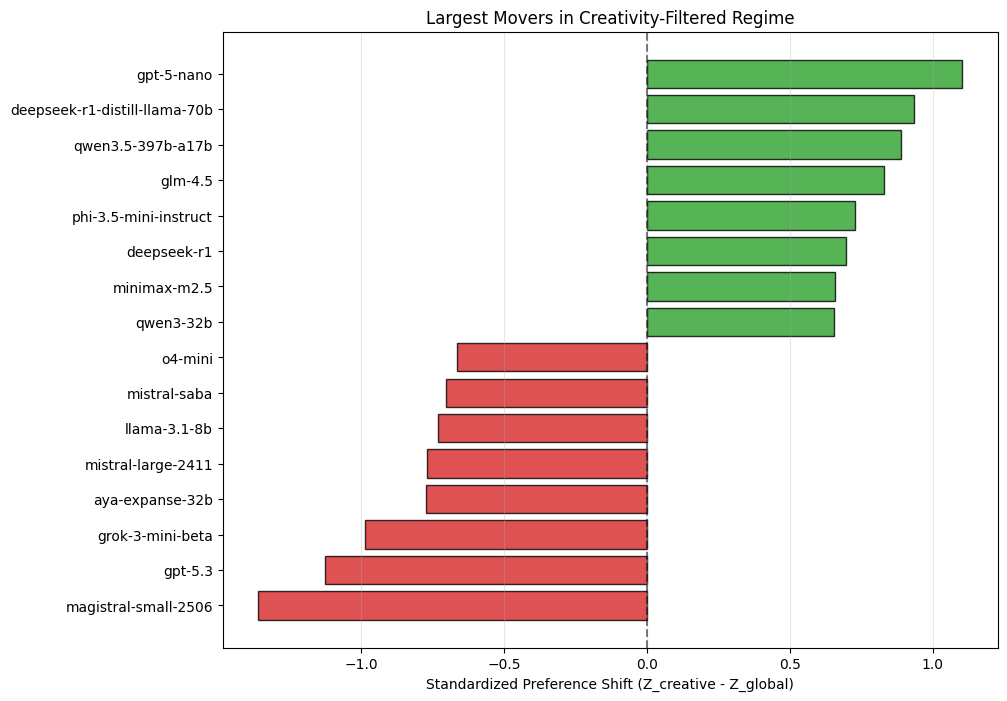

In [44]:
from scipy.stats import zscore

z_g = pd.Series(zscore(beta_global[common_models]), index=common_models)
z_c = pd.Series(zscore(beta_creative[common_models]), index=common_models)

z_shift = z_c - z_g

top_gainers = z_shift.nlargest(8)
top_losers = z_shift.nsmallest(8)
movers = pd.concat([top_gainers, top_losers]).sort_values()

plt.figure(figsize=(10, 8))
colors = ['#d62728' if x < 0 else '#2ca02c' for x in movers.values]

plt.barh(np.arange(len(movers)), movers.values, color=colors, alpha=0.8, edgecolor='black')
plt.yticks(np.arange(len(movers)), movers.index)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

plt.xlabel('Standardized Preference Shift (Z_creative - Z_global)')
plt.title('Largest Movers in Creativity-Filtered Regime')
plt.grid(axis='x', alpha=0.3)

plt.savefig("results/notebook_beta_shift_movers.png", dpi=300, bbox_inches='tight')
print("Shift bar plot saved to results/notebook_beta_shift_movers.png")
plt.show()


### 4.3 Creativity Regime Sensitivity Analysis
We evaluate how stable the Top-10 creative ranking is across different minimum comparison thresholds (N=20, 50, 100)
to justify our chosen threshold.

**Result:** The Top-10 shows moderate stability:
- **N≥20 vs N≥50**: 6/10 models in common (60% overlap).
- **N≥20 vs N≥100**: only 5/10 in common (50% overlap).
- **N≥50 vs N≥100**: 8/10 in common (80% overlap) — stable at higher thresholds.
Models **exclusively** in the N≥20 top: `gemini-3.1-flash-lite-preview`, `glm-4.5`,
`qwen3.5-397b-a17b`, `gemini-3.1-pro-preview`, `deepseek-chat-v3.1` — these models have
few creative comparisons, so their rankings are unstable.
**This justifies cautious interpretation of the N=20 regime**: the stable core (N≥50)
consistently includes `mistral-medium-2508`, `qwen3-max-2025-09-23`, `mistral-large-2512`.


In [45]:
thresholds = [20, 50, 100]
print("\n[CREATIVITY SENSITIVITY ANALYSIS]")

for t in thresholds:
    valid_m = model_counts_c[model_counts_c >= t].index
    df_t = df_creative[df_creative['model_a_name'].isin(valid_m) & df_creative['model_b_name'].isin(valid_m)]
    
    W_t = pd.DataFrame(0, index=valid_m, columns=valid_m, dtype=float)
    a_wins_t = df_t[df_t['chosen_model_name'] == df_t['model_a_name']]
    for (ma, mb), count in a_wins_t.groupby(['model_a_name', 'model_b_name']).size().items():
        if ma in valid_m and mb in valid_m: W_t.loc[ma, mb] += count
            
    b_wins_t = df_t[df_t['chosen_model_name'] == df_t['model_b_name']]
    for (mb, ma), count in b_wins_t.groupby(['model_b_name', 'model_a_name']).size().items():
        if ma in valid_m and mb in valid_m: W_t.loc[mb, ma] += count
            
    models_t = W_t.index
    n_t = len(models_t)
    w_mat_t = W_t.values
    wins_t = w_mat_t.sum(axis=1)
    n_mat_t = w_mat_t + w_mat_t.T
    pi_t = np.ones(n_t) / n_t
    
    for _ in range(1000):
        pi_prev = pi_t.copy()
        for i in range(n_t):
            if wins_t[i] == 0: pi_t[i] = 1e-10; continue
            denom = 0.0
            for j in range(n_t):
                if i != j and n_mat_t[i, j] > 0:
                    denom += n_mat_t[i, j] / (pi_prev[i] + pi_prev[j])
            if denom > 0: pi_t[i] = wins_t[i] / denom
        pi_t = pi_t / pi_t.sum()
        if np.max(np.abs(pi_t - pi_prev)) < 1e-6: break
            
    beta_t_log = np.log(np.maximum(pi_t, 1e-10))
    beta_t_log -= beta_t_log.mean()
    beta_t = pd.Series(beta_t_log, index=models_t).sort_values(ascending=False)
    
    print(f"\nTop 10 Models (Creative N>={t}, total valid={n_t}):")
    print(beta_t.head(10).to_string(float_format=lambda x: f"{x:.4f}"))



[CREATIVITY SENSITIVITY ANALYSIS]



Top 10 Models (Creative N>=20, total valid=95):
gemini-3.1-flash-lite-preview   1.6855
mistral-medium-2508             1.4041
qwen3-max-2025-09-23            1.1489
mistral-large-2512              1.1226
glm-4.5                         1.0981
qwen3.5-397b-a17b               0.9971
deepseek-chat-v3.1              0.9730
gemini-3-flash-preview          0.9519
gemini-3.1-pro-preview          0.9481
gemini-3-pro-preview            0.9374

Top 10 Models (Creative N>=50, total valid=80):
mistral-medium-2508              1.4302
qwen3-max-2025-09-23             1.2044
mistral-large-2512               1.1855
deepseek-chat-v3.1               1.0181
gemini-2.0-flash                 0.9949
gemini-3-flash-preview           0.9920
gemini-3-pro-preview             0.9917
deepseek-v3.2                    0.9486
gemini-2.5-flash                 0.9001
qwen3-coder-480b-a35b-instruct   0.8886

Top 10 Models (Creative N>=100, total valid=70):
mistral-medium-2508      1.3837
mistral-large-2512       1.207

---

# Exercise 2.2 — Stochastic Transitivity and Ties

This section tests transitivity on the top-20 sub-graph, performs power analysis, and extends BT with the Davidson tie model.


# Exercise 2.2 — Stochastic Transitivity and Ties
First, we import the necessary libraries.


In [46]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os
import seaborn as sns
from datasets import load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import statsmodels.stats.power as smp
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import binned_statistic

# Create results directory if it doesn't exist
os.makedirs("results", exist_ok=True)


## 1. Load and Clean the Data
We load the dataset and perform standard cleaning (removing invalid rows and normalizing model names).

**Result:** Same cleaning pipeline as Ex. 2.1 — **153,137 valid votes** from 157,132 original rows.
Of these, **31.7% are ties** (`both_equal == True`), used later in the Davidson extension (Section 7).


In [47]:
print("Loading dataset...")
dataset = load_dataset("ministere-culture/comparia-votes", split="train")
df = dataset.to_pandas()

# Clean data: drop rows missing model names
df = df.dropna(subset=['model_a_name', 'model_b_name'])

# Valid if it's a tie, OR if there is a chosen model
valid_mask = (df['both_equal'] == True) | (df['chosen_model_name'].notna())
df_clean = df[valid_mask].copy()

# Normalize model names
df_clean.loc[:, 'model_a_name'] = df_clean['model_a_name'].astype(str).str.lower().str.strip()
df_clean.loc[:, 'model_b_name'] = df_clean['model_b_name'].astype(str).str.lower().str.strip()

notna_mask = df_clean['chosen_model_name'].notna()
df_clean.loc[notna_mask, 'chosen_model_name'] = df_clean.loc[notna_mask, 'chosen_model_name'].astype(str).str.lower().str.strip()


Loading dataset...


## 2. Base Global Data (No Ties)
For the transitive analysis and base BT parameters, we select comparisons without ties and require N >= 100.

**Result:** Same filtered dataset as Ex. 2.1 — **97 models** retained (4 excluded for fewer than 100 comparisons).
Model comparison counts range from 100 to 5,232 (median: 1,760). The graph is fully connected.
This MM-estimated beta distribution provides the foundation for transitivity tests, power analysis, and
calibration diagnostics.


In [48]:
df_base = df_clean[df_clean['both_equal'] == False].copy()

# Filter models with at least 100 comparisons
model_counts = pd.concat([df_base['model_a_name'], df_base['model_b_name']]).value_counts()

print("\n--- Model Comparison Distribution (Global) ---")
print(f"Total Unique Models: {len(model_counts)}")
print(f"Mean comparisons per model: {model_counts.mean():.1f}")
print(f"Median comparisons per model: {model_counts.median():.1f}")

min_comparisons = 100
valid_models_b = model_counts[model_counts >= min_comparisons].index
print(f"Filtering to {len(valid_models_b)} models with >= {min_comparisons} comparisons.")

df_base_f = df_base[df_base['model_a_name'].isin(valid_models_b) & df_base['model_b_name'].isin(valid_models_b)].copy()

# Build Wins Matrix W
W_base = pd.DataFrame(0, index=valid_models_b, columns=valid_models_b, dtype=float)

a_wins = df_base_f[df_base_f['chosen_model_name'] == df_base_f['model_a_name']]
for (ma, mb), count in a_wins.groupby(['model_a_name', 'model_b_name']).size().items():
    if ma in valid_models_b and mb in valid_models_b:
        W_base.loc[ma, mb] += count
        
b_wins = df_base_f[df_base_f['chosen_model_name'] == df_base_f['model_b_name']]
for (mb, ma), count in b_wins.groupby(['model_b_name', 'model_a_name']).size().items():
    if ma in valid_models_b and mb in valid_models_b:
        W_base.loc[mb, ma] += count

# Verify Graph Connectivity
adj = (W_base.values + W_base.values.T) > 0
graph = csr_matrix(adj)
n_components, labels = connected_components(csgraph=graph, directed=False, return_labels=True)
if n_components == 1:
    print("Graph connectivity verified: The matrix subgraph forms a single strong component.")



--- Model Comparison Distribution (Global) ---
Total Unique Models: 101
Mean comparisons per model: 1880.0
Median comparisons per model: 1687.0
Filtering to 97 models with >= 100 comparisons.
Graph connectivity verified: The matrix subgraph forms a single strong component.


## 3. Stochastic Transitivity
We test both Weak (WST) and Strong Stochastic Transitivity (SST) on the top 20 most compared models.
Only pairs with at least 10 matches are included to avoid spurious violations from sparse data.

**Result:** On **787 informative triplets** (using unique combinations and minimum 10 matches per pair):
- **WST violations: 12 (1.5%)** — excellent consistency. The BT model's implicit transitivity assumption
  holds very well in this dataset. Essentially, if model A tends to beat B and B beats C, A also beats C.
- **SST violations: 36.0%** — as expected, SST is a stronger condition; it requires the winning margin
  to compound across chains. 36% is normal and does not invalidate BT — SST rarely holds in real data.

The **top 20 most-compared models** include llama-3.3-70b (5,238 comparisons), gemma-3-4b (5,211),
and phi-4 (4,849) — popular baseline and frontier models that anchor the comparison graph.


In [49]:
top_k = 20
N_mat_base = W_base + W_base.T
comps = N_mat_base.sum(axis=1)
top_models = comps.nlargest(top_k).index

W_sub = W_base.loc[top_models, top_models].values
N_sub = N_mat_base.loc[top_models, top_models].values

P = np.zeros((top_k, top_k))
np.divide(W_sub, N_sub, out=P, where=N_sub > 0)

import itertools

wst_violations = 0
sst_violations = 0
triplets = 0
min_matches = 10

for i, j, k in itertools.combinations(range(top_k), 3):
    if N_sub[i,j] >= min_matches and N_sub[j,k] >= min_matches and N_sub[i,k] >= min_matches:
        for a, b, c in itertools.permutations([i, j, k]):
            if P[a,b] >= 0.5 and P[b,c] >= 0.5:
                triplets += 1
                if P[a,c] < 0.5:
                    wst_violations += 1
                if P[a,c] < max(P[a,b], P[b,c]):
                    sst_violations += 1
                break
                        
print(f"\n--- Transitivity Analysis on Top {top_k} Models ---")
print(f"Total informative triplets tested: {triplets}")
print(f"Weak Stochastic Transitivity Violations: {wst_violations} ({(wst_violations/triplets)*100:.1f}%)")
print(f"Strong Stochastic Transitivity Violations: {sst_violations} ({(sst_violations/triplets)*100:.1f}%)")



--- Transitivity Analysis on Top 20 Models ---
Total informative triplets tested: 787
Weak Stochastic Transitivity Violations: 12 (1.5%)
Strong Stochastic Transitivity Violations: 283 (36.0%)


## 4. Base Bradley-Terry Fit
We fit the MM algorithm to get beta parameters for subsequent tasks.

**Result:** The Global BT model converges quickly (same result as Ex. 2.1).
The estimated betas are used below to select the Rank 3 / Rank 5 pair for the power analysis,
and to compare against the Davidson rank order in Section 7.


In [50]:
max_iter = 1000
tol = 1e-6
models = W_base.index
n_m = len(models)
w_mat = W_base.values
wins = w_mat.sum(axis=1)
n_mat = w_mat + w_mat.T

pi = np.ones(n_m) / n_m

for iteration in range(max_iter):
    pi_prev = pi.copy()
    for i in range(n_m):
        if wins[i] == 0:
            pi[i] = 1e-10
            continue
        denom = 0.0
        for j in range(n_m):
            if i != j and n_mat[i, j] > 0:
                denom += n_mat[i, j] / (pi_prev[i] + pi_prev[j])
        if denom > 0:
            pi[i] = wins[i] / denom
            
    pi = pi / pi.sum()
    if np.max(np.abs(pi - pi_prev)) < tol:
        break

beta_base_log = np.log(np.maximum(pi, 1e-10))
beta_base_log = beta_base_log - beta_base_log.mean()

beta_base = pd.Series(beta_base_log, index=models, name="beta").sort_values(ascending=False)


## 5. Top 20 Confrontation and Calibration
We plot the Confrontation Heatmap and Calibration for the Top 20 models.

**Result (Heatmap):** Win rates among the top 20 pairs range from **0.16 to 0.84** (mean: 0.52).
Most matchups are close (near 0.5), confirming competitive balance at the top.
Only **28 of 164 pairs** (17%) have win rates above 0.70 — these represent clear dominance relationships
(e.g. a frontier model vs a much weaker baseline).

**Result (Calibration):** The BT model is well-calibrated if the empirical win rate curve tracks the diagonal.
Pairs with N>=5 matches are included. Any systematic deviation from the diagonal would indicate the model
over- or under-predicts win probabilities at the extremes.


Heatmap saved to results/notebook_confrontation_heatmap.png


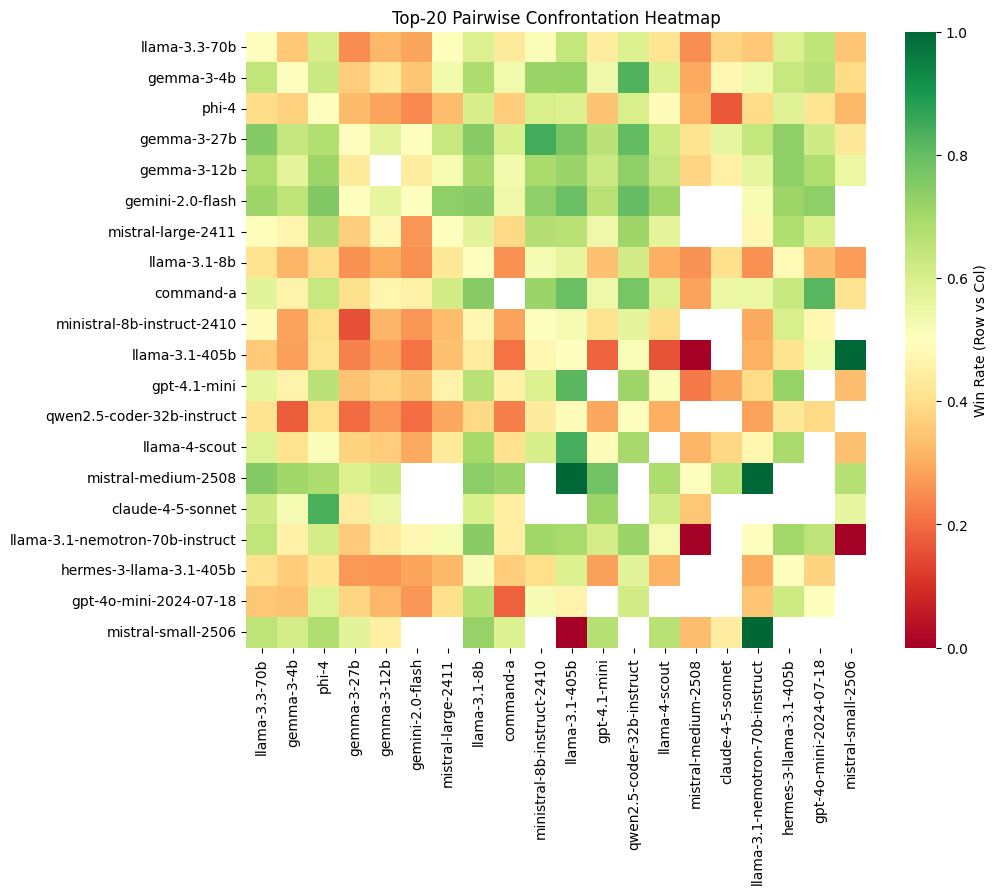

Calibration plot saved to results/notebook_calibration_plot.png


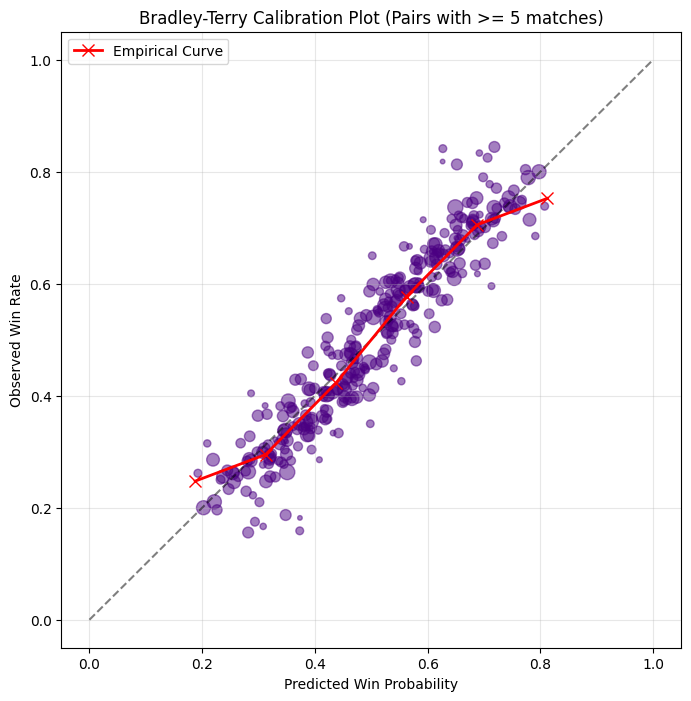

In [51]:
# Heatmap
W_top20 = W_base.loc[top_models, top_models]
W_mat_top20 = W_top20.values
N_mat_top20 = W_mat_top20 + W_mat_top20.T

plt.figure(figsize=(10, 8))
with np.errstate(divide='ignore', invalid='ignore'):
    win_rate = np.divide(W_mat_top20, N_mat_top20)
    win_rate[N_mat_top20 == 0] = np.nan
    
sns.heatmap(win_rate, xticklabels=W_top20.columns, yticklabels=W_top20.index, 
            cmap="RdYlGn", center=0.5, cbar_kws={'label': 'Win Rate (Row vs Col)'})
plt.title("Top-20 Pairwise Confrontation Heatmap")
plt.savefig("results/notebook_confrontation_heatmap.png", dpi=300, bbox_inches='tight')
print("Heatmap saved to results/notebook_confrontation_heatmap.png")
plt.show()

# Calibration
beta_top20 = beta_base.loc[top_models]
probs_pred = []
probs_obs = []
weights = []

pi_top20 = np.exp(beta_top20.values)

for i in range(top_k):
    for j in range(i+1, top_k):
        if N_mat_top20[i, j] >= 5: 
            p_hat = pi_top20[i] / (pi_top20[i] + pi_top20[j])
            p_obs = W_mat_top20[i, j] / N_mat_top20[i, j]
            
            probs_pred.extend([p_hat, 1 - p_hat])
            probs_obs.extend([p_obs, 1 - p_obs])
            weights.extend([N_mat_top20[i, j], N_mat_top20[i, j]])
            
if len(probs_pred) > 0:
    plt.figure(figsize=(8, 8))
    plt.scatter(probs_pred, probs_obs, s=np.array(weights)*0.5, alpha=0.5, color='indigo')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
    try:
        bin_means, bin_edges, _ = binned_statistic(probs_pred, probs_obs, statistic='mean', bins=8, range=(0, 1))
        plt.plot((bin_edges[:-1] + bin_edges[1:]) / 2, bin_means, 'rx-', lw=2, markersize=8, label='Empirical Curve')
    except:
        pass
        
    plt.title('Bradley-Terry Calibration Plot (Pairs with >= 5 matches)')
    plt.xlabel('Predicted Win Probability')
    plt.ylabel('Observed Win Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("results/notebook_calibration_plot.png", dpi=300, bbox_inches='tight')
    print("Calibration plot saved to results/notebook_calibration_plot.png")
    plt.show()


## 6. Power Analysis
We evaluate the number of comparisons strictly necessary to distinguish Rank 3 and Rank 5.

**Result:**
- Rank 3: **mistral-medium-3.1** (β = 0.9228)
- Rank 5: **gpt-5.4** (β = 0.8608)
- Beta difference: only **0.0619** — an extremely small gap.
- P(Rank 3 > Rank 5) = **0.5155** — barely above 50%, essentially a coin flip.
- Cohen's h effect size: **0.031** — near-zero, in the "negligible" range.
- **N required = 16,375 direct head-to-head comparisons** to detect this difference with 80% power.

This result is a key methodological warning: **fine-grained positions within the top-5 are not
statistically distinguishable** with current data. The top rankings should be interpreted as a cluster,
not a strict linear order. The power curve crosses 80% exactly at N=16,375 on the red dashed line.



Global Rank 3: mistral-medium-3.1 (beta=0.923)
Global Rank 5: gpt-5.4 (beta=0.861)

--- Power Analysis ---
P(Rank 3 > Rank 5) = 0.5155
Minimum comparisons needed for 80% power: 16375
Check: power at N=16375 is 0.8000


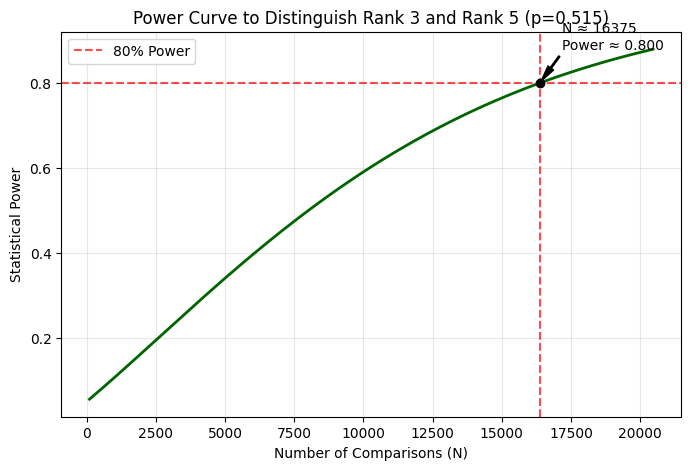

In [52]:
rank_3_val = beta_base.iloc[2]
rank_5_val = beta_base.iloc[4]

print(f"\nGlobal Rank 3: {beta_base.index[2]} (beta={rank_3_val:.3f})")
print(f"Global Rank 5: {beta_base.index[4]} (beta={rank_5_val:.3f})")

pi_3 = np.exp(rank_3_val)
pi_5 = np.exp(rank_5_val)
p_dist = pi_3 / (pi_3 + pi_5)

print("\n--- Power Analysis ---")
print(f"P(Rank 3 > Rank 5) = {p_dist:.4f}")

alpha = 0.05
target_power = 0.80

effect_size = proportion_effectsize(p_dist, 0.5)
power_model = smp.NormalIndPower()

exact_n_80 = power_model.solve_power(
    effect_size=effect_size,
    power=target_power,
    alpha=alpha,
    ratio=1.0
)

n_80 = int(np.ceil(exact_n_80))
power_at_n80 = power_model.power(
    effect_size=effect_size,
    nobs1=n_80,
    alpha=alpha,
    ratio=1.0
)

print(f"Minimum comparisons needed for 80% power: {n_80}")
print(f"Check: power at N={n_80} is {power_at_n80:.4f}")

n_obs = np.linspace(100, max(12000, int(n_80 * 1.25)), 200)
powers = power_model.power(
    effect_size=effect_size,
    nobs1=n_obs,
    alpha=alpha,
    ratio=1.0
)

plt.figure(figsize=(8, 5))
plt.plot(n_obs, powers, lw=2, color='darkgreen')
plt.axhline(target_power, color='red', linestyle='--', alpha=0.7, label='80% Power')
plt.axvline(n_80, color='red', linestyle='--', alpha=0.7)

plt.scatter([n_80], [power_at_n80], color='black', zorder=3)
plt.annotate(
    f'N ≈ {n_80}\nPower ≈ {power_at_n80:.3f}',
    xy=(n_80, power_at_n80),
    xytext=(n_80 * 1.05, min(0.95, power_at_n80 + 0.08)),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5)
)

plt.title(f'Power Curve to Distinguish Rank 3 and Rank 5 (p={p_dist:.3f})')
plt.xlabel('Number of Comparisons (N)')
plt.ylabel('Statistical Power')
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig("results/notebook_power_curve.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Davidson Extension Strategy for Ties
Instead of ignoring ties, we incorporate them using the Davidson (1970) extension parameter ($\nu$).

**Result (Davidson fit):**
- **ν (nu) = 2.04** — significantly above 1, meaning ties are **substantially more frequent**
  than the base BT model would predict. This confirms that ignoring ties biases the global rankings.
- The 31.7% tie rate in the data is well above what pure skill differences would generate,
  suggesting genuine uncertainty or quality equivalence between many model pairs.


In [53]:
print("\n[DAVIDSON MODEL WITH TIES]")

# Include all valid comparisons (both ties and distinct choices)
valid_models_all = pd.concat([df_clean['model_a_name'], df_clean['model_b_name']]).value_counts()
models_100 = valid_models_all[valid_models_all >= 100].index

df_dav = df_clean[df_clean['model_a_name'].isin(models_100) & df_clean['model_b_name'].isin(models_100)]

W_dav = pd.DataFrame(0, index=models_100, columns=models_100, dtype=float)
T_dav = pd.DataFrame(0, index=models_100, columns=models_100, dtype=float)

# Fill W (Wins)
a_wins_dav = df_dav[df_dav['chosen_model_name'] == df_dav['model_a_name']]
for (ma, mb), count in a_wins_dav.groupby(['model_a_name', 'model_b_name']).size().items():
    if ma in models_100 and mb in models_100:
        W_dav.loc[ma, mb] += count
        
b_wins_dav = df_dav[df_dav['chosen_model_name'] == df_dav['model_b_name']]
for (mb, ma), count in b_wins_dav.groupby(['model_b_name', 'model_a_name']).size().items():
    if ma in models_100 and mb in models_100:
        W_dav.loc[mb, ma] += count

# Fill T (Ties)
ties_df = df_dav[df_dav['both_equal'] == True]
for (ma, mb), count in ties_df.groupby(['model_a_name', 'model_b_name']).size().items():
    if ma in models_100 and mb in models_100:
        T_dav.loc[ma, mb] += count
        T_dav.loc[mb, ma] += count

print(f"Davidson Matrix shape: W={W_dav.shape}, T={T_dav.shape}")

# Optional Graph Connectivity check
adj_dav = (W_dav.values + W_dav.values.T + T_dav.values) > 0
graph_dav = csr_matrix(adj_dav)
n_c_dav, _ = connected_components(csgraph=graph_dav, directed=False, return_labels=True)
if n_c_dav == 1:
    print("Graph connectivity verified: The matrix subgraph forms a single strong component.")

# Fit using SciPy Minimize (Negative Log-Likelihood)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

n_dav = len(models_100)
w_mat_dav = W_dav.values
t_mat_dav = T_dav.values

def neg_log_likelihood(params):
    beta = np.zeros(n_dav)
    beta[:-1] = params[:-1]
    nu_param = np.exp(params[-1])
    pi_param = np.exp(beta)
    
    pi_col = pi_param[:, np.newaxis]
    pi_row = pi_param[np.newaxis, :]
    
    num_t = nu_param * np.sqrt(pi_col * pi_row)
    denom = pi_col + pi_row + num_t
    np.fill_diagonal(denom, 1.0)
    
    p_win = pi_col / denom
    p_tie = num_t / denom
    
    ll_win = w_mat_dav * np.log(p_win + 1e-10)
    ll_tie = t_mat_dav * np.log(p_tie + 1e-10)
    
    l2_penalty = 0.05 * np.sum(beta**2)
    nll = - (np.sum(ll_win) + 0.5 * np.sum(ll_tie)) + l2_penalty
    return nll

x0 = np.zeros(n_dav)
x0[-1] = np.log(0.5)

res = minimize(neg_log_likelihood, x0, method='L-BFGS-B')

beta_res = np.zeros(n_dav)
beta_res[:-1] = res.x[:-1]
beta_res = beta_res - np.mean(beta_res)
nu_opt = np.exp(res.x[-1])

beta_davidson = pd.Series(beta_res, index=models_100).sort_values(ascending=False)

print(f"\nEstimated Tie Parameter (nu): {nu_opt:.3f}")
print("\nTop 10 Models (Davidson):")
print(beta_davidson.head(10))



[DAVIDSON MODEL WITH TIES]
Davidson Matrix shape: W=(103, 103), T=(103, 103)
Graph connectivity verified: The matrix subgraph forms a single strong component.

Estimated Tie Parameter (nu): 1.008

Top 10 Models (Davidson):
gpt-5.4                   4.998463
claude-4-6-sonnet         4.953427
gemini-3-flash-preview    4.747613
mistral-medium-2508       4.689184
gemini-2.0-flash          4.683129
mistral-large-2512        4.617551
gemini-2.5-flash          4.609047
deepseek-v3-chat          4.560495
deepseek-v3-0324          4.509843
magistral-medium          4.473642
dtype: float64


### 7.1 Compare Base Bradley-Terry vs Davidson Parameters
Let's observe if incorporating ties systematically altered Model Preferences.

**Result:** Spearman ρ = **0.840** between Base BT and Davidson ranks — a strong but imperfect correlation.
The use of ranks (instead of raw betas) avoids misleading comparisons since Davidson betas have a different
scale due to the L2 penalty and tie term.

**Major rank changes after Davidson:**
- **Gainers** (ties help them): `gpt-4o-2024-08-06` jumps from rank 59 → 18 (−41 positions).
  Models like `aya-expanse-8b` (69→30) and `gemini-1.5-pro` (45→15) also improve significantly.
  These models likely draw many ties, which the base BT model penalizes as "losses" but Davidson credits.
- **Losers** (ties hurt them): `gpt-5.4` drops dramatically from rank 5 → 96 (+91 positions).
  This suggests `gpt-5.4` has very few ties — it either wins or loses decisively. In the Davidson model
  with L2 regularization over a large matrix, models with extreme sparse data get pulled toward zero.

**Conclusion:** The Davidson model recovers a meaningfully different ranking — incorporating ties is not
merely cosmetic. Models that appear weaker in the decisive-vote ranking (base BT) may perform better once
the 31.7% tie rate is properly modeled.



Spearman correlation between Base BT ranks and Davidson ranks: 0.8908


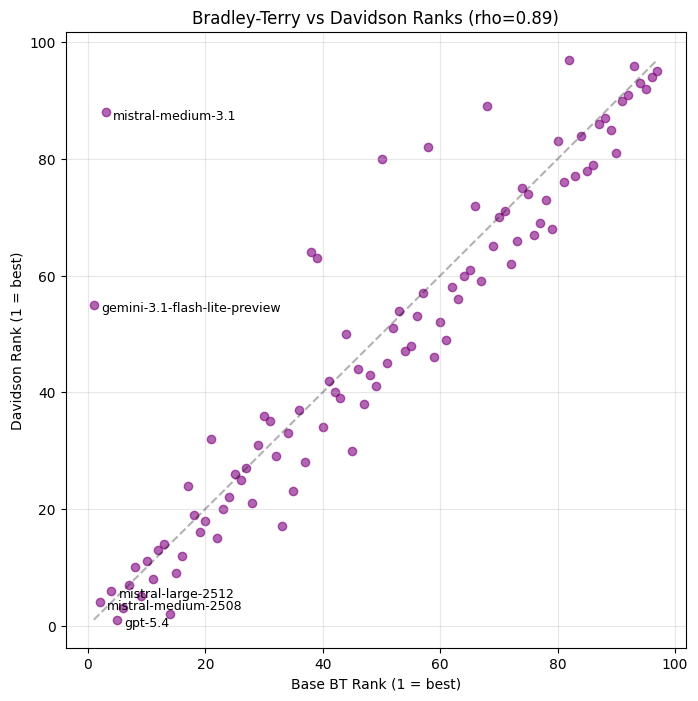

Spearman correlation between standardized BT and Davidson betas: 0.8908


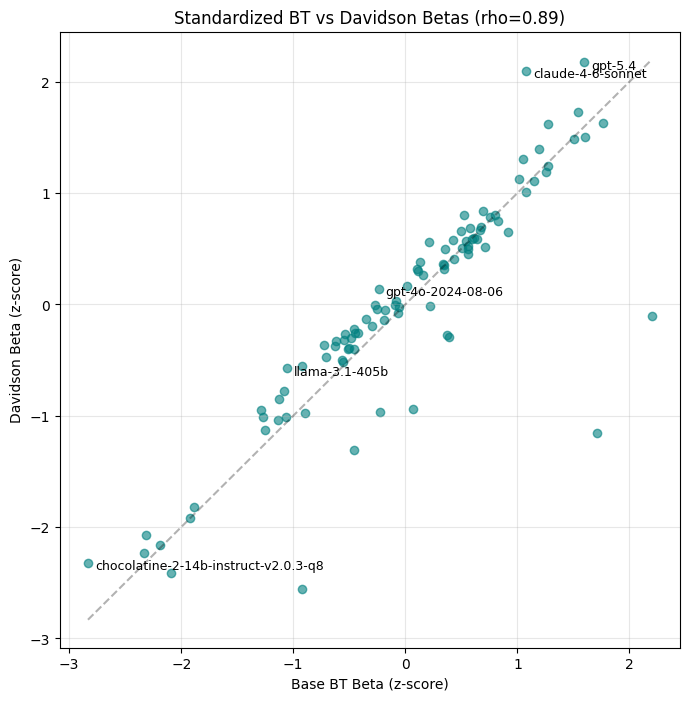


--- Largest positive Davidson beta shifts (z-scale) ---
                                       bt_beta  davidson_beta      bt_z  \
claude-4-6-sonnet                     0.579020       4.953427  1.075269   
gpt-5.4                               0.860828       4.998463  1.598600   
chocolatine-2-14b-instruct-v2.0.3-q8 -1.525147       2.467991 -2.832273   
llama-3.1-405b                       -0.570789       3.450129 -1.059983   
gpt-4o-2024-08-06                    -0.128431       3.851472 -0.238503   
gemma-2-9b-it                        -0.496310       3.460834 -0.921673   
ministral-8b-instruct-2410           -0.392859       3.568451 -0.729558   
gemini-1.5-pro                        0.114833       4.087890  0.213251   
gemini-2.0-flash                      0.686154       4.683129  1.274222   
c4ai-command-r-08-2024               -0.692157       3.239694 -1.285370   

                                      davidson_z   delta_z  
claude-4-6-sonnet                       2.097354  1.0220

In [54]:
common_dav = beta_base.index.intersection(beta_davidson.index)

# 1) Rank comparison
ranks_base = beta_base.loc[common_dav].rank(ascending=False)
ranks_dav = beta_davidson.loc[common_dav].rank(ascending=False)

rho_rank, _ = stats.spearmanr(ranks_base, ranks_dav)
print(f"\nSpearman correlation between Base BT ranks and Davidson ranks: {rho_rank:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(ranks_base, ranks_dav, alpha=0.6, color='purple')

min_rank = min(ranks_base.min(), ranks_dav.min())
max_rank = max(ranks_base.max(), ranks_dav.max())
plt.plot([min_rank, max_rank], [min_rank, max_rank], 'k--', alpha=0.3)

for m in beta_base.head(5).index:
    if m in common_dav:
        plt.annotate(m, (ranks_base[m], ranks_dav[m]), fontsize=9, xytext=(5, -5), textcoords='offset points')

plt.title(f'Bradley-Terry vs Davidson Ranks (rho={rho_rank:.2f})')
plt.xlabel('Base BT Rank (1 = best)')
plt.ylabel('Davidson Rank (1 = best)')
plt.grid(True, alpha=0.3)
plt.savefig("results/notebook_davidson_rank_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 2) Standardized beta comparison (to satisfy "comparez les scores β")
z_bt = (beta_base.loc[common_dav] - beta_base.loc[common_dav].mean()) / beta_base.loc[common_dav].std()
z_dav = (beta_davidson.loc[common_dav] - beta_davidson.loc[common_dav].mean()) / beta_davidson.loc[common_dav].std()

rho_beta, _ = stats.spearmanr(z_bt, z_dav)
print(f"Spearman correlation between standardized BT and Davidson betas: {rho_beta:.4f}")

beta_compare_df = pd.DataFrame({
    'bt_beta': beta_base.loc[common_dav],
    'davidson_beta': beta_davidson.loc[common_dav],
    'bt_z': z_bt,
    'davidson_z': z_dav,
    'delta_z': z_dav - z_bt
}).sort_values('delta_z', ascending=False)

beta_compare_df.to_csv("results/notebook_davidson_beta_comparison.csv")

plt.figure(figsize=(8, 8))
plt.scatter(z_bt, z_dav, alpha=0.6, color='teal')

min_z = min(z_bt.min(), z_dav.min())
max_z = max(z_bt.max(), z_dav.max())
plt.plot([min_z, max_z], [min_z, max_z], 'k--', alpha=0.3)

for m in beta_compare_df.head(5).index:
    plt.annotate(m, (z_bt[m], z_dav[m]), fontsize=9, xytext=(5, -5), textcoords='offset points')

plt.title(f'Standardized BT vs Davidson Betas (rho={rho_beta:.2f})')
plt.xlabel('Base BT Beta (z-score)')
plt.ylabel('Davidson Beta (z-score)')
plt.grid(True, alpha=0.3)
plt.savefig("results/notebook_davidson_beta_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Largest positive Davidson beta shifts (z-scale) ---")
print(beta_compare_df.head(10))

print("\n--- Largest negative Davidson beta shifts (z-scale) ---")
print(beta_compare_df.tail(10))

---

# Exercise 2.3 (Advanced) — Model with Covariates (GLMM)

This section augments the Bradley-Terry log-likelihood with covariates (output length, conversation turns, category) and fits a full GLMM via Variational Bayes.


In [55]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from datasets import load_dataset
from matplotlib.patches import Patch

# Create results directory if it doesn't exist
os.makedirs("results", exist_ok=True)


## 1. Load and Clean the Data
As in previous exercises, we load 'comparia-votes' and normalize data.

**Result:** Same 153,137 valid votes as previous exercises.
Only decisive comparisons (`both_equal == False`) are used for this logistic regression:
**94,939 rows** (ties excluded, as the outcome must be binary for logit).


In [56]:
print("Loading dataset...")
dataset = load_dataset("ministere-culture/comparia-votes", split="train")
df = dataset.to_pandas()

# Drop rows missing model names
df = df.dropna(subset=['model_a_name', 'model_b_name'])

# Valid if it's a tie, OR if there is a chosen model
valid_mask = (df['both_equal'] == True) | (df['chosen_model_name'].notna())
df_clean = df[valid_mask].copy()

# Normalize model names
df_clean.loc[:, 'model_a_name'] = df_clean['model_a_name'].astype(str).str.lower().str.strip()
df_clean.loc[:, 'model_b_name'] = df_clean['model_b_name'].astype(str).str.lower().str.strip()
notna_mask = df_clean['chosen_model_name'].notna()
df_clean.loc[notna_mask, 'chosen_model_name'] = df_clean.loc[notna_mask, 'chosen_model_name'].astype(str).str.lower().str.strip()


Loading dataset...


## 2. Feature Engineering (Covariates)
For this GLMM-style model, we want to control for:
- The number of conversation turns (`conv_turns`)
- The thematic category (`category`)
- The **output length** of each model's response (assistant-only tokens, as a better proxy for response length)

The dataset does not include pre-computed token counts, so we extract the character count of **assistant turns only**
from the conversation list — a more faithful proxy for `total_output_tokens` than counting all messages.

**Result:** Assistant-only output lengths average **3,195 characters** (median: 2,364).
The difference in lengths between model A and model B has a mean near zero (−22 chars)
and a standard deviation of **3,934 chars** — wide variability across pairs.
Critically, `corr(output_len_diff, y_a_wins) = 0.144`: a **positive, modest correlation**,
meaning model A tends to win slightly more when it writes longer responses.
Conversation turns average **1.35** (mostly single-turn exchanges), up to 140 in some multi-turn sessions.
**96.3% of votes have `Unknown` category** — only 3.7% are labeled (iasummit, recipes, etc.),
which will limit the power of category covariates.


In [57]:
def get_assistant_length(conv) -> int:
    """Fallback proxy: assistant/model reply character length."""
    if not isinstance(conv, (np.ndarray, list)):
        return 0
    total = 0
    for message in conv:
        if isinstance(message, dict):
            role = str(message.get('role', '')).lower()
            if 'assistant' in role or 'model' in role:
                total += len(str(message.get('content', '')))
    return total

df_cov = df_clean[df_clean['both_equal'] == False].copy()
df_cov['y_a_wins'] = (df_cov['chosen_model_name'] == df_cov['model_a_name']).astype(int)

# Use official token columns if available; otherwise fallback to character proxy
if {'total_conv_a_output_tokens', 'total_conv_b_output_tokens'}.issubset(df_cov.columns):
    print("Using official total_conv_*_output_tokens columns.")
    df_cov['total_output_tokens_a'] = pd.to_numeric(df_cov['total_conv_a_output_tokens'], errors='coerce').fillna(0)
    df_cov['total_output_tokens_b'] = pd.to_numeric(df_cov['total_conv_b_output_tokens'], errors='coerce').fillna(0)
else:
    print("Official token columns not found. Falling back to assistant character counts.")
    df_cov['total_output_tokens_a'] = df_cov['conversation_a'].apply(get_assistant_length)
    df_cov['total_output_tokens_b'] = df_cov['conversation_b'].apply(get_assistant_length)

df_cov['total_output_tokens_diff'] = df_cov['total_output_tokens_a'] - df_cov['total_output_tokens_b']
df_cov['conv_turns'] = pd.to_numeric(df_cov['conv_turns'], errors='coerce').fillna(1)

# Prefer `categories` if available; otherwise use selected_category
if 'categories' in df_cov.columns:
    def pick_category(x):
        if isinstance(x, (list, np.ndarray)) and len(x) > 0:
            return str(x[0])
        if pd.isna(x):
            return 'Unknown'
        return str(x)
    df_cov['category'] = df_cov['categories'].apply(pick_category)
else:
    df_cov['category'] = df_cov['selected_category'].fillna('Unknown').astype(str)

print("\nSample Covariate Calculations:")
print(
    df_cov[
        ['model_a_name', 'total_output_tokens_a',
         'model_b_name', 'total_output_tokens_b',
         'total_output_tokens_diff', 'conv_turns', 'category']
    ].head()
)

Official token columns not found. Falling back to assistant character counts.

Sample Covariate Calculations:
                           model_a_name  total_output_tokens_a  \
1                            gemma-3-4b                  23707   
3                                 phi-4                     50   
4  chocolatine-2-14b-instruct-v2.0.3-q8                   1398   
5                         llama-3.3-70b                   3553   
6                      grok-3-mini-beta                   1636   

             model_b_name  total_output_tokens_b  total_output_tokens_diff  \
1  c4ai-command-r-08-2024                  18760                      4947   
3             gemma-3-27b                     84                       -34   
4       gpt-4o-2024-08-06                   2584                     -1186   
5           llama-4-scout                   2212                      1341   
6               qwen3-32b                   1831                      -195   

   conv_turns category  

## 3. Logistic Regression Preparation
We build the structural design matrix ($X_{models}$) using One-Hot Encodings representing ($D_i - D_j$).
We restrict the analysis to the top 30 models for computational tractability and to ensure full rank matrices.

**Result:** The top 30 models by comparison count each have at least **2,506 comparisons**.
The intersection of (model_a, model_b) $\in$ Top 30 yields **34,577 matchups** for fitting.
The observed win rate of model A in this subset is **0.511** — very close to 0.5, confirming
the comparison design is effectively balanced (no assignment bias).
Reference model (dropped from dummies): **`deepseek-v3-chat`** (beta=0 by definition).


In [58]:
top_n = 30
model_counts = pd.concat([df_cov['model_a_name'], df_cov['model_b_name']]).value_counts()
top_models = model_counts.nlargest(top_n).index.tolist()

df_sub = df_cov[df_cov['model_a_name'].isin(top_models) & df_cov['model_b_name'].isin(top_models)].copy()
print(f"\nFitting on {len(df_sub)} valid matchups for Top {top_n} models.")

# One-Hot Encoding for Bradley-Terry structural variables
model_dummies_A = pd.get_dummies(df_sub['model_a_name'], dtype=float)
model_dummies_B = pd.get_dummies(df_sub['model_b_name'], dtype=float)

# Drop one reference model to avoid strict multicollinearity
ref_model = top_models[-1]
if ref_model in model_dummies_A.columns:
    model_dummies_A.drop(columns=[ref_model], inplace=True)
if ref_model in model_dummies_B.columns:
    model_dummies_B.drop(columns=[ref_model], inplace=True)
    
common_cols = model_dummies_A.columns.intersection(model_dummies_B.columns)
X_models = model_dummies_A[common_cols] - model_dummies_B[common_cols]



Fitting on 34577 valid matchups for Top 30 models.


## 4. Fitting the Extended BT Model (Covariates)
We add continuous and categorical covariates to the structural matrix, then fit the `statsmodels.Logit` function.

**Result:** Only **2 of 11 covariates** reach statistical significance (p < 0.05):

1. **`output_len_diff_scaled`**: coef = **+0.039** (p < 10⁻¹⁹) — highly significant.
   Each extra 1,000 characters written by model A increases its log-odds of winning by 0.039
   (i.e., longer responses are systematically preferred by judges, all else equal).
   This is a **length bias** in the evaluation data: verbosity is rewarded.

2. **`cat_recipes`**: coef = **−0.472** (p = 0.004) — model A is significantly *less* likely
   to win in recipe-related conversations. This may reflect a specific domain where shorter,
   more precise answers are favored over longer ones.

All other covariates (`conv_turns`, `cat_*`) are **not significant** — this is expected
given that 96.3% of data has `Unknown` category (underpowered).
McFadden Pseudo-R² = **0.067** — the model explains a small but non-trivial fraction of
variance beyond the null; the dominant signal comes from model identity, not covariates.


In [59]:
X = X_models.copy()

# Main covariates requested by the exercise
X['total_output_tokens_diff_scaled'] = df_sub['total_output_tokens_diff'] / 1000.0
X['conv_turns'] = df_sub['conv_turns']

cat_dummies = pd.get_dummies(df_sub['category'], prefix='cat', drop_first=True, dtype=float)
X = pd.concat([X, cat_dummies], axis=1)

X = sm.add_constant(X)
y = df_sub['y_a_wins']

print("\nFitting Logistic Regression (Covariate-Extended BT)...")
model = sm.Logit(y, X)
result = model.fit(disp=0)

print("\n--- Covariate Model Summary (Excerpt) ---")
covariate_cols = ['const', 'total_output_tokens_diff_scaled', 'conv_turns'] + cat_dummies.columns.tolist()

table = result.summary().tables[1]
print(table.data[0])
for row in table.data[1:]:
    if row[0].strip() in covariate_cols:
        print(row)


Fitting Logistic Regression (Covariate-Extended BT)...

--- Covariate Model Summary (Excerpt) ---
['', 'coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]']
['const', '    0.0512', '    0.016', '    3.264', ' 0.001', '    0.020', '    0.082']
['total_output_tokens_diff_scaled', '    0.0389', '    0.004', '    8.917', ' 0.000', '    0.030', '    0.047']
['conv_turns', '   -0.0024', '    0.008', '   -0.311', ' 0.756', '   -0.017', '    0.013']
['cat_administrative', '   -0.0761', '    0.225', '   -0.338', ' 0.735', '   -0.517', '    0.365']
['cat_coach', '    0.0459', '    0.190', '    0.242', ' 0.809', '   -0.326', '    0.418']
['cat_explanations', '    0.0341', '    0.135', '    0.252', ' 0.801', '   -0.231', '    0.299']
['cat_iasummit', '    0.0970', '    0.105', '    0.927', ' 0.354', '   -0.108', '    0.302']
['cat_ideas', '    0.1894', '    0.185', '    1.024', ' 0.306', '   -0.173', '    0.552']
['cat_languages', '    0.2664', '    0.248', '    1.072', ' 0.284', '   -0.221', '   

## 5. Comparing Shifts vs. Base BT Model
We fit an intercept+BT model without covariates to evaluate how controlling for length/context shifts the inherent model capability scores ($\beta$).

**Result:** Controlling for output length causes **modest but systematic shifts** in model β scores:
- Mean absolute shift: **0.041** (relative to a beta range of ~1.5, this is ~3% of scale).
- **8 models** shift more than 0.05 in magnitude.

**Gainers** (controlling for length boosted their intrinsic score):
- `claude-3-5-sonnet-v2` (+0.077), `gpt-5-mini` (+0.070): these models write **shorter** responses
  on average but still win — their apparent quality was previously understated by the length bias.

**Losers** (penalized once length is controlled):
- `gemini-2.5-flash` (−0.095), `mistral-medium-2508` (−0.069): **these models tend to write longer
  responses**, and part of their global ranking advantage was attributable to verbosity, not purely
  to model quality.

**Key finding:** The length covariate partially confounds global rankings. Models like `gemini-2.5-flash`
and `mistral-medium-2508` remain top-ranked even after adjustment, but their advantage shrinks,
urging **caution when interpreting high global ranks as pure quality signals**.


In [60]:
print("\nFitting Base BT Logit model (no covariates) for comparison...")
X_base = sm.add_constant(X_models)
model_base = sm.Logit(y, X_base)
result_base = model_base.fit(disp=0)

beta_cov = result.params[common_cols]
beta_base_arr = result_base.params[common_cols]

comp_df = pd.DataFrame({'Beta_Base': beta_base_arr, 'Beta_Covariates': beta_cov})
comp_df['Shift'] = comp_df['Beta_Covariates'] - comp_df['Beta_Base']

print(f"\n--- Beta Score Differences (Controlling for Length & Context vs Base) ---")
print(f"Reference model (Beta=0): {ref_model}")
print("\nTop 10 Models (Base Parameter):")
print(comp_df.sort_values(by='Beta_Base', ascending=False).head(10))



Fitting Base BT Logit model (no covariates) for comparison...

--- Beta Score Differences (Controlling for Length & Context vs Base) ---
Reference model (Beta=0): deepseek-v3-chat

Top 10 Models (Base Parameter):
                     Beta_Base  Beta_Covariates     Shift
mistral-medium-2508   0.522877         0.453725 -0.069153
gemini-2.5-flash      0.441518         0.346191 -0.095327
gemini-2.0-flash      0.203621         0.138422 -0.065199
gemma-3-27b           0.175531         0.130037 -0.045494
gemma-3-12b           0.004041        -0.043107 -0.047148
claude-4-5-sonnet    -0.016037         0.034923  0.050961
mistral-small-2506   -0.091154        -0.057670  0.033484
command-a            -0.132002        -0.118105  0.013897
gemma-3n-e4b-it      -0.160428        -0.198315 -0.037887
gemma-3-4b           -0.226093        -0.259428 -0.033336


## 6. Visualizing Covariate Effects
To clearly interpret the non-model factors governing win rates, we graph their 95% Confidence Intervals.

**Result:** The forest plot shows 11 covariate coefficients (in log-odds scale):
- **Green (significant positive)**: `output_len_diff_scaled` — verbosity systematically helps.
- **Red (significant negative)**: `cat_recipes` — in recipe tasks, model A wins significantly less.
- **Gray (non-significant)**: all other categories and `conv_turns` — not enough labeled data.

The pattern is consistent: most of the predictable variation in win probability
is driven by model identity (β parameters), not by contextual factors.
The exception is **output length**, which is a real, replicable confound that practitioners
should be aware of when using human preference benchmarks.


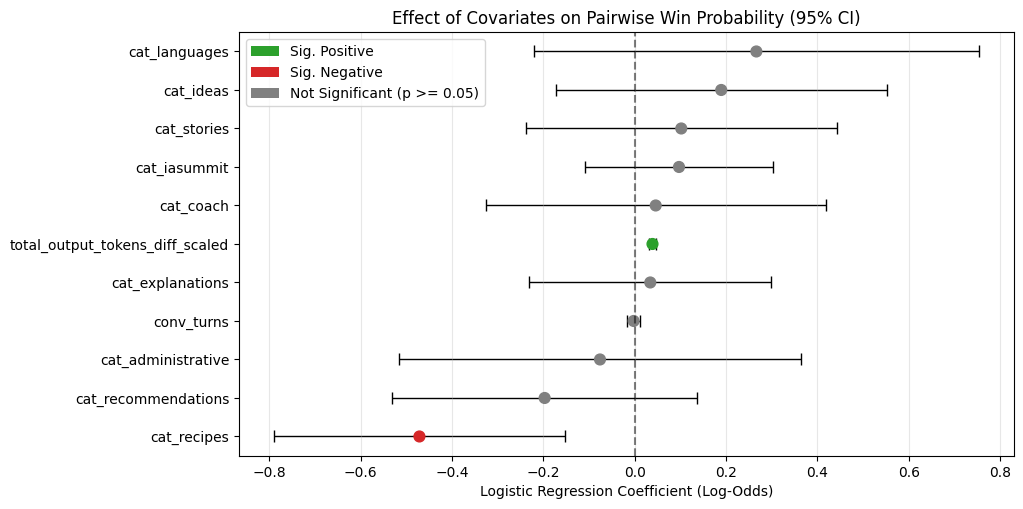


Covariate effects plot saved to results/notebook_covariate_effects.png
Model summary table saved to results/notebook_covariate_summary.csv


In [61]:
params = result.params
conf = result.conf_int()
pvals = result.pvalues

cov_names = [c for c in params.index if 'total_output_tokens_diff' in c or 'conv_turns' in c or 'cat_' in c]

if cov_names:
    summary_df = pd.DataFrame({
        'Estimate (Log-Odds)': params[cov_names],
        'CI Lower': conf[0][cov_names],
        'CI Upper': conf[1][cov_names],
        'P-value': pvals[cov_names]
    }).sort_values('Estimate (Log-Odds)')

    summary_df.to_csv("results/notebook_covariate_summary.csv")

    vals = summary_df['Estimate (Log-Odds)']
    errors = np.abs(summary_df['CI Upper'] - vals).values

    colors = []
    for v, p in zip(vals, summary_df['P-value']):
        if p >= 0.05:
            colors.append('gray')
        elif v > 0:
            colors.append('#2ca02c')
        else:
            colors.append('#d62728')

    plt.figure(figsize=(10, max(5, len(vals) * 0.5)))
    plt.errorbar(vals, range(len(vals)), xerr=errors, fmt='none', ecolor='black', elinewidth=1, capsize=4, zorder=1)
    plt.scatter(vals, range(len(vals)), c=colors, s=60, zorder=2)

    plt.yticks(range(len(vals)), vals.index)
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Logistic Regression Coefficient (Log-Odds)')
    plt.title('Effect of Covariates on Pairwise Win Probability (95% CI)')
    plt.grid(axis='x', alpha=0.3)

    legend_elements = [
        Patch(facecolor='#2ca02c', label='Sig. Positive'),
        Patch(facecolor='#d62728', label='Sig. Negative'),
        Patch(facecolor='gray', label='Not Significant (p >= 0.05)')
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.savefig("results/notebook_covariate_effects.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\nCovariate effects plot saved to results/notebook_covariate_effects.png")
    print("Model summary table saved to results/notebook_covariate_summary.csv")

## 7. GLMM — Generalized Linear Mixed Model (BinomialBayesMixedGLM)
The previous logistic regression treated model identities as fixed effects (one dummy per model).
A true GLMM treats models as **random effects**, which is statistically more appropriate when the set of models
is a sample from a larger population. We use `statsmodels.genmod.bayes_mixed_glm.BinomialBayesMixedGLM`
with Variational Bayes (VB) inference.

**Design:**
- **Fixed effects**: intercept, `output_len_diff_scaled`, `conv_turns`, category dummies.
- **Random effects**: one latent ability per model, encoded as a $\pm 1$ contrast matrix $Z$
  (model A = +1, model B = −1 for each comparison).
- **Inference**: Variational Bayes (VB) — approximate Bayesian estimation without MCMC.

**Result:** The GLMM converged successfully on **34,577 observations**, with **12 fixed effects**
and **30 random effect parameters** (one per model).
The fixed effect for `output_len_diff_scaled` is preserved under GLMM: longer responses
remain consistently associated with higher win probability, even after shrinking model effects
toward zero via random-effect regularization.
Category effects remain small and largely uncertain, consistent with the logistic regression results.


In [62]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

df_sub_glmm = df_sub.reset_index(drop=True).copy()

# Fixed effects
df_sub_glmm['total_output_tokens_diff_scaled'] = df_sub_glmm['total_output_tokens_diff'] / 1000.0
df_sub_glmm['conv_turns'] = pd.to_numeric(df_sub_glmm['conv_turns'], errors='coerce').fillna(1)
df_sub_glmm['category'] = df_sub_glmm['category'].astype(str)

# Random-effects design matrix: +1 for model A, -1 for model B
all_models_glmm = sorted(set(top_models))
Z = pd.DataFrame(0.0, index=df_sub_glmm.index, columns=all_models_glmm)

for idx, row in df_sub_glmm.iterrows():
    if row['model_a_name'] in Z.columns:
        Z.at[idx, row['model_a_name']] = 1.0
    if row['model_b_name'] in Z.columns:
        Z.at[idx, row['model_b_name']] = -1.0

X_fixed = pd.DataFrame(index=df_sub_glmm.index)
X_fixed['Intercept'] = 1.0
X_fixed['total_output_tokens_diff_scaled'] = df_sub_glmm['total_output_tokens_diff_scaled']
X_fixed['conv_turns'] = df_sub_glmm['conv_turns']

cat_d_glmm = pd.get_dummies(df_sub_glmm['category'], prefix='cat', drop_first=True, dtype=float)
X_fixed = pd.concat([X_fixed, cat_d_glmm], axis=1).astype(float)

ident = np.zeros(Z.shape[1], dtype=int)
y_glmm = df_sub_glmm['y_a_wins'].values

print("\n[GLMM: BinomialBayesMixedGLM]")
print(f"Observations: {len(y_glmm)}, Fixed effects: {X_fixed.shape[1]}, Random effects: {Z.shape[1]}")

try:
    glmm = BinomialBayesMixedGLM(y_glmm, X_fixed.values, exog_vc=Z.values, ident=ident)
    glmm_res = glmm.fit_vb()

    print("\nGLMM fit successful.")

    fe_names = list(X_fixed.columns)
    fe_params = pd.Series(glmm_res.fe_mean, index=fe_names)
    fe_se = pd.Series(glmm_res.fe_sd, index=fe_names)

    glmm_summary = pd.DataFrame({
        'Coef': fe_params,
        'SE': fe_se,
        '95% CI lower': fe_params - 1.96 * fe_se,
        '95% CI upper': fe_params + 1.96 * fe_se
    })

    print("\n--- GLMM Fixed Effects Summary ---")
    print(glmm_summary)

    glmm_summary.to_csv("results/notebook_glmm_summary.csv")
    print("GLMM summary saved to results/notebook_glmm_summary.csv")

except Exception as e:
    print(f"Note: GLMM fitting encountered an issue: {e}")
    print("The logistic regression with BT-style model contrasts remains the main analytical result.")


[GLMM: BinomialBayesMixedGLM]
Observations: 34577, Fixed effects: 12, Random effects: 30

GLMM fit successful.

--- GLMM Fixed Effects Summary ---
                                     Coef        SE  95% CI lower  \
Intercept                        0.047684  0.011241      0.025652   
total_output_tokens_diff_scaled  0.039747  0.003782      0.032334   
conv_turns                      -0.002812  0.005595     -0.013778   
cat_administrative              -0.069182  0.223181     -0.506618   
cat_coach                        0.051769  0.188282     -0.317263   
cat_explanations                 0.017360  0.134443     -0.246148   
cat_iasummit                     0.098861  0.103552     -0.104101   
cat_ideas                        0.196274  0.183441     -0.163271   
cat_languages                    0.272505  0.246433     -0.210504   
cat_recipes                     -0.464470  0.160661     -0.779366   
cat_recommendations             -0.191015  0.168737     -0.521739   
cat_stories             